### Production EfficientNetV2L CNN Training Using YOLO-Processed Chum Salmon Scale Images

This script trains the productionEfficientNetV2Le convolutional neural network using YOLO-processed chum salmon scale images from AFSC, ADF&G, DFO, and NSRAA.

The YOLO-processed images were randomly divided into training (70%), validation (15%), and test (15%) datasets, stratified by total age to maintain a similar age-class distribution across each dataset. Each dataset was stored in a separate directory on disk.

The script loads and standardizes the images and trains the model using a two-phase transfer-learning strategy. The final trained model, including its architecture and learned weights, is saved to disk for subsequent evaluation and inference.ence.


Date: 07/01/2025

In [1]:
#loading packages

from PIL import Image
import numpy as np
import pandas as pd
import tensorrt
import io
import cx_Oracle 
import numpy.random as nr
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras
#import keras.utils.np_utils as ku
import keras.layers as layers
from keras import optimizers
import time

%matplotlib inline

2025-07-19 13:16:57.549851: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
start = time.time()

In [3]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
  try:
    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
    logical_gpus = tf.config.list_logical_devices('GPU')
    print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
  except RuntimeError as e:
    print(e)

2 Physical GPUs, 2 Logical GPUs


2025-07-19 13:16:58.799831: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-07-19 13:16:58.799984: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-07-19 13:16:58.805691: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

### Counting images in folder

In [4]:
# counting the total number of images within the folder
import glob
import random
import os, shutil

import os

def count_images_in_folder(folder_path):
    if not folder_path.endswith('/'):
        folder_path += '/'
    
    files = os.listdir(folder_path)
    
    image_extensions = ('.png', '.tif', '.tiff', '.jpg', '.jpeg')
    
    image_files = [f for f in files if f.lower().endswith(image_extensions)]
    
    num_images = len(image_files)

    return num_images

#folder_training_path = '/opt/chumputer/scale_images/nsraa_10292024/NSRAA_copies_10292024/SAM_NSRAA_train' #/opt/chumputer/scale_images/Image_copies_code_testing_SAMgood/Training' 
#folder_validation_path = '/opt/chumputer/scale_images/ImageSAM_copies_model_testing' #/opt/chumputer/scale_images/Image_copies_code_testing_SAMgood/Validation'

#YOLO
#folder_training_path = '/opt/chumputer/scale_images/Image_yolo_code_testing_good/evaltraining' 
#folder_validation_path = '/opt/chumputer/scale_images/Image_yolo_code_testing_good/evalval'

folder_training_path = '/opt/chumputer/scale_images/Image_yolo_code_testing_good/Training_550_tif' 
folder_validation_path = '/opt/chumputer/scale_images/Image_yolo_code_testing_good/Validation_550_tif'

num_images = count_images_in_folder(folder_training_path)
print(f'Number of images in {folder_training_path}: {num_images}')

Number of images in /opt/chumputer/scale_images/Image_yolo_code_testing_good/Training_550_tif: 11012


### Counting images in folder by age class

In [5]:
import os

def count_images_in_folder(folder_path):
    if not folder_path.endswith('/'):
        folder_path += '/'
    
    image_extensions = ('.png', '.tif', '.tiff', '.jpg', '.jpeg')
    
    files = os.listdir(folder_path)

    counts = {
        '_1': 0, '_2': 0, '_3': 0, '_4': 0,
        '_5': 0, '_6': 0, '_7': 0
    }
    
    for file in files:
        if file.lower().endswith(image_extensions):
            base_name = os.path.splitext(file)[0].lower()
            
            for label in counts.keys():
                if base_name.endswith(label):
                    counts[label] += 1
                    break

    return counts

counts = count_images_in_folder(folder_training_path)
print(f"Counts of images in {folder_training_path}:")
for label, count in counts.items():
    print(f"{label}: {count}")

Counts of images in /opt/chumputer/scale_images/Image_yolo_code_testing_good/Training_550_tif:
_1: 123
_2: 76
_3: 2767
_4: 4265
_5: 3602
_6: 172
_7: 7


In [6]:
# loop through image in memory and extracts the age class label from the end of the file name 
# and create a pandas dataframe that includes the filename and label (total age). 

import os
import pandas as pd

def load_images_from_folder(folder_path):
    """Load image filenames from a folder and return them in a DataFrame."""
    labels = ['_1', '_2', '_3', '_4', '_5', '_6', '_7']
    files_by_label = {label: [] for label in labels}
    
    # Loop through files in the folder and group them by label
    for file in os.listdir(folder_path):
        for label in labels:
            if file.lower().endswith(label + '.png') or \
               file.lower().endswith(label + '.jpg') or \
               file.lower().endswith(label + '.jpeg') or \
               file.lower().endswith(label + '.tif') or \
               file.lower().endswith(label + '.tiff'):
                files_by_label[label].append(file)
    
    # Create a list of tuples (filename, label)
    data = [(file, label) for label, files in files_by_label.items() for file in files]
    
    # Return as DataFrame
    return pd.DataFrame(data, columns=['filename', 'label'])

# Load images from both the training and validation folders
df_train = load_images_from_folder(folder_training_path)
df_val = load_images_from_folder(folder_validation_path)
#df_test = load_images_from_folder(folder_testing_path)

# Print samples of the data
print("Training set sample:")
print(df_train.head())
print(f"Total images in training set: {len(df_train)}")

print("\nValidation set sample:")
print(df_val.head())
print(f"Total images in validation set: {len(df_val)}")

# print("\nTesting set sample:")
# print(df_test.head())
# print(f"Total images in validation set: {len(df_test)}")


Training set sample:
                  filename label
0   Chum_SCL_2004_92_1.tif    _1
1  Chum_SCL_2002_144_1.tif    _1
2   Chum_SCL_2007_16_1.tif    _1
3   Chum_SCL_2004_95_1.tif    _1
4  Chum_SCL_2002_129_1.tif    _1
Total images in training set: 11012

Validation set sample:
                  filename label
0   Chum_SCL_2006_07_1.tif    _1
1  Chum_SCL_2002_115_1.tif    _1
2  Chum_SCL_2002_125_1.tif    _1
3   Chum_SCL_2011_01_1.tif    _1
4  Chum_SCL_2002_148_1.tif    _1
Total images in validation set: 2365


In [7]:
df_val['label'] = df_val['label'].str.replace(r'_(\d+)', r'\1', regex=True)
df_val['label'] = pd.to_numeric(df_val['label'], errors='coerce')

# df_test['label'] = df_test['label'].str.replace(r'_(\d+)', r'\1', regex=True)
# df_test['label'] = pd.to_numeric(df_test['label'], errors='coerce')

df_train['label'] = df_train['label'].str.replace(r'_(\d+)', r'\1', regex=True)
df_train['label'] = pd.to_numeric(df_train['label'], errors='coerce')

df_train.head()

,filename,label
0,Chum_SCL_2004_92_1.tif,1
1,Chum_SCL_2002_144_1.tif,1
2,Chum_SCL_2007_16_1.tif,1
3,Chum_SCL_2004_95_1.tif,1
4,Chum_SCL_2002_129_1.tif,1


In [8]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11012 entries, 0 to 11011
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  11012 non-null  object
 1   label     11012 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 172.2+ KB


In [9]:
val_images_link = df_val['filename'].tolist()
val_labels = df_val['label'].tolist()

# test_images_link = df_test['filename'].tolist()
# test_labels = df_test['label'].tolist()

train_images_link = df_train['filename'].tolist()
train_labels = df_train['label'].tolist()

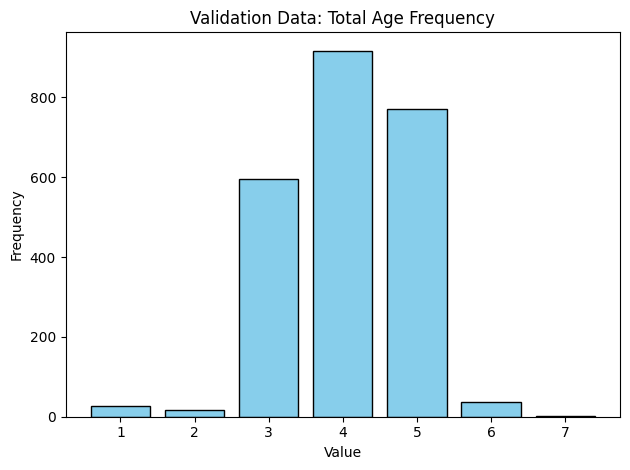

In [10]:
from collections import Counter

count_data = Counter(val_labels)

x = list(count_data.keys())
y = list(count_data.values())

plt.bar(x, y, color='skyblue', edgecolor='black')

plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Validation Data: Total Age Frequency')

plt.tight_layout()
#plt.savefig('ValidationAgeLabels.pdf') 
plt.show()

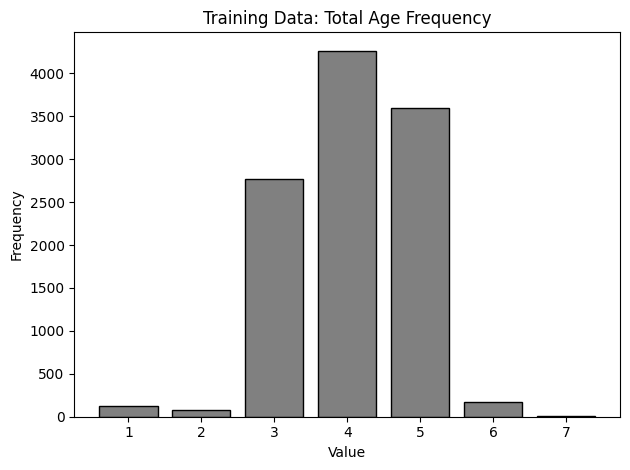

In [11]:
from collections import Counter

count_data = Counter(train_labels)

x = list(count_data.keys())
y = list(count_data.values())

plt.bar(x, y, color='gray', edgecolor='black')

plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Training Data: Total Age Frequency')

plt.tight_layout()
#plt.savefig('TrainingAgeLabels.pdf') 
plt.show()

In [12]:
from PIL import Image
import os

train_images = {}
val_images = {}
# test_images = {}

def load_images(image_filenames, folder_path):
    images = {}
    target_size = (512, 512)

    for filename in image_filenames:
        file_path = os.path.join(folder_path, filename)
        if os.path.exists(file_path):
            with Image.open(file_path) as img:
                resized_img = img.resize(target_size, Image.LANCZOS)
                images[filename] = resized_img.copy()
        else:
            print(f"File {filename} not found in {folder_path}")
    
    return images


train_images = load_images(train_images_link, folder_training_path)
val_images = load_images(val_images_link, folder_validation_path)


In [13]:
from PIL import Image
import numpy as np
import cv2
from tqdm import tqdm

def process_image(img):

    if not isinstance(img, Image.Image):
        raise TypeError("Input has to be a PIL.Image.Image object.")
    
    img_np = np.array(img)
    
    print(f"Processing image with shape: {img_np.shape}")
    
    if len(img_np.shape) == 2:
        img_rgb = cv2.cvtColor(img_np, cv2.COLOR_GRAY2RGB)
    elif len(img_np.shape) == 3:
        if img_np.shape[2] == 1:
            img_rgb = np.repeat(img_np, 3, axis=2)
        elif img_np.shape[2] == 3:
            img_rgb = img_np
        else:
            raise ValueError(f"Unexpected number of channels in the image: {img_np.shape[2]}")
    else:
        raise ValueError(f"Unexpected image dimensions: {img_np.shape}")
    
    return img_rgb

def process_images(image_dict):
    processed_images = []
    error_count = 0
    for filename, img in tqdm(image_dict.items(), desc="Processing Images"):
        try:
            processed_img = process_image(img)
            processed_images.append(processed_img)
        except (TypeError, ValueError) as e:
            print(f"Error processing {filename}: {e}")
            error_count += 1
    
    print(f"Number of errors: {error_count}")
    return processed_images


In [14]:
processed_train_images = process_images(train_images)
processed_train_images = np.array(processed_train_images)
x_train = processed_train_images.astype("float32") / 255

processed_val_images = process_images(val_images) 
processed_val_images = np.array(processed_val_images)
x_val = processed_val_images.astype("float32") / 255

# processed_test_images = process_images(test_images) 
# processed_test_images = np.array(processed_test_images)
# x_test = processed_test_images.astype("float32") / 255

for img in val_images.values():
    img.close()
# for img in test_images.values():
#     img.close()
for img in train_images.values():
    img.close()

Processing Images:   5%|██▊                                                       | 541/11012 [00:00<00:03, 2930.85it/s]

Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing 

Processing Images:  13%|███████▋                                                 | 1483/11012 [00:00<00:02, 4128.08it/s]

Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)


Processing Images:  22%|████████████▌                                            | 2428/11012 [00:00<00:01, 4466.96it/s]

...

Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with 

Processing Images:  79%|█████████████████████████████████████████████▌            | 1857/2365 [00:00<00:00, 9304.10it/s]

Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing 

Processing Images: 100%|██████████████████████████████████████████████████████████| 2365/2365 [00:00<00:00, 8816.43it/s]


Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512)
Processing image with shape: (512, 512, 3)
Processing image with shape:

In [15]:
print("x_train shape:", x_train.shape)
print(x_train.shape[0], "train samples")
# print(x_test.shape[0], "test samples")
print(x_val.shape[0], "val samples")

x_train shape: (11012, 512, 512, 3)
11012 train samples
2365 val samples


In [16]:
y_val_class = np.asarray([float(num) - 1 for num in val_labels])
y_train_class = np.asarray([float(num) - 1 for num in train_labels])
# y_test_class = np.asarray([float(num) - 1 for num in test_labels])

In [17]:
import gc

del train_images, val_images, df_train, df_val, processed_train_images, processed_val_images
gc.collect()

0

In [18]:
import tensorflow as tf
tf.keras.backend.clear_session()

In [19]:
print("GPU available: ", tf.config.list_physical_devices('GPU'))

GPU available:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


### Loading EfficientNetV2L model

In [20]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.applications import EfficientNetV2L
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers.legacy import Adam  #  legacy version to avoid KeyError
#from tensorflow.keras.optimizers.legacy import SGD
import gc
import tensorflow.keras.backend as K



#Create a MirroredStrategy for multi-GPU usage
strategy = tf.distribute.MirroredStrategy()

print(f"Number of devices: {strategy.num_replicas_in_sync}")

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Number of devices: 2


In [21]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

# def add_noise(image):
#     noise_factor = 0.06
#     noise = np.random.normal(0, noise_factor, image.shape)
#     image_noisy = image + noise
#     return np.clip(image_noisy, 0., 255.)

datagen = ImageDataGenerator(
    rotation_range=360,
    vertical_flip=True,
    horizontal_flip=True,
    shear_range=0.15,
    zoom_range=[0.97, 1.02],
    height_shift_range=0.04,
    width_shift_range=0.04,
    fill_mode='nearest',
    cval=255
#    preprocessing_function=add_noise
)

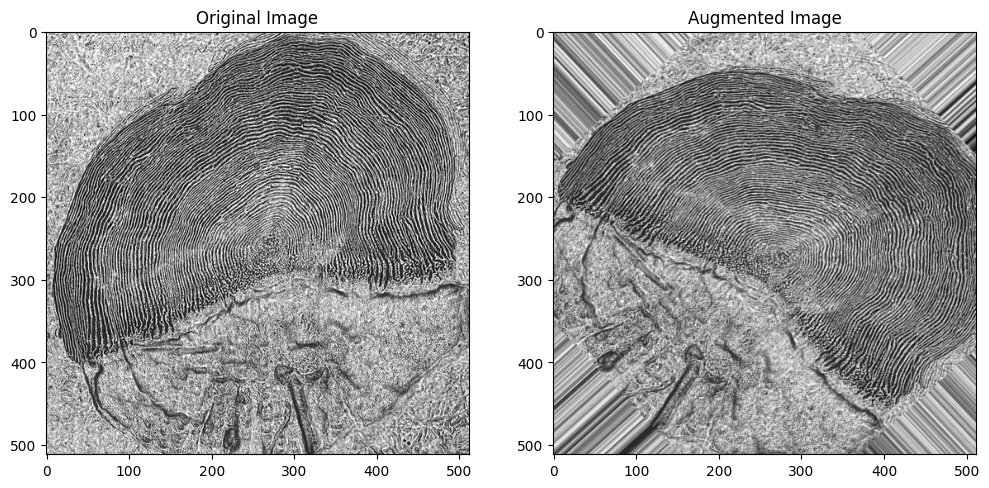

In [22]:
index_to_visualize = 3891
image_to_visualize = x_train[index_to_visualize]

image_to_visualize = np.expand_dims(image_to_visualize, axis=0)

plt.figure(figsize=(12, 12))
plt.subplot(1, 2, 1)
plt.imshow(image_to_visualize[0])
plt.title('Original Image')

augmented_image = datagen.flow(image_to_visualize).next()[0]

plt.subplot(1, 2, 2)
plt.imshow(augmented_image)
plt.title('Augmented Image')

#plt.savefig('ExampleAugmentedImageProcess.pdf')
plt.show()

In [23]:
strategy = tf.distribute.MirroredStrategy()

input_shape = (512, 512, 3)
batch_size = 16
learning_rate = 1e-4
max_epochs = 150
initial_epochs = 75
patience = 9

effnetv2l_train_generator = datagen.flow(x_train, y_train_class, batch_size=batch_size)

with strategy.scope():
    pretrained_effnetv2l = EfficientNetV2L(
        weights='imagenet', 
        include_top=False, 
        include_preprocessing=False, 
        input_shape=input_shape)

    # Freeze the first one-third of the layers
    num_layers = len(pretrained_effnetv2l.layers)
    one_third_index = num_layers // 3
    for layer in pretrained_effnetv2l.layers[:one_third_index]:
        layer.trainable = False

    x = GlobalAveragePooling2D()(pretrained_effnetv2l.output)
    x = Dense(4096, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = Dropout(0.5)(x)
    predictions = Dense(1, activation='linear')(x)

    effnetv2lmodel = Model(inputs=pretrained_effnetv2l.input, outputs=predictions)

    # Compile the model within the strategy scope
    optimizer = Adam(learning_rate=learning_rate)
    effnetv2lmodel.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mse'])

effnetv2lfilepath = 'effnetv2l_yolo_model_tif_phase1.hdf5'

checkpoint_cb = ModelCheckpoint(
    filepath=effnetv2lfilepath,
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False, 
    verbose=1
)

callbacks_list = [
    EarlyStopping(patience=patience, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=4, min_lr=1e-12, verbose=1),
    checkpoint_cb  
]

# Phase 1 Training 
print(f"Training first {initial_epochs} epochs with the first 1/3 of network frozen")
effnetv2lhistory_phase1 = effnetv2lmodel.fit(
    effnetv2l_train_generator,
    steps_per_epoch=len(x_train) // batch_size,
    epochs=initial_epochs,
    validation_data=(x_val, y_val_class),
    callbacks=callbacks_list
)

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensor

2025-07-19 13:18:54.738956: W tensorflow/core/grappler/optimizers/data/auto_shard.cc:786] AUTO sharding policy will apply DATA sharding policy as it failed to apply FILE sharding policy because of the following reason: Found an unshardable source dataset: name: "TensorDataset/_1"
op: "TensorDataset"
input: "Placeholder/_0"
attr {
  key: "Toutput_types"
  value {
    list {
      type: DT_INT32
    }
  }
}
attr {
  key: "_cardinality"
  value {
    i: 1
  }
}
attr {
  key: "metadata"
  value {
    s: "\n\017TensorDataset:0"
  }
}
attr {
  key: "output_shapes"
  value {
    list {
      shape {
      }
    }
  }
}
experimental_type {
  type_id: TFT_PRODUCT
  args {
    type_id: TFT_DATASET
    args {
      type_id: TFT_PRODUCT
      args {
        type_id: TFT_TENSOR
        args {
          type_id: TFT_INT32
        }
      }
    }
  }
}



INFO:tensorflow:Collective all_reduce tensors: 601 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
INFO:tensorflow:Collective all_reduce tensors: 601 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1


2025-07-19 13:19:51.482882: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodel/block1b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2025-07-19 13:20:04.612421: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8907
2025-07-19 13:20:04.626724: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8907
2025-07-19 13:20:05.220929: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:606] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


688/688 [==============================] - ETA: 0s - loss: 0.7691 - mse: 0.5786
Epoch 1: val_loss improved from inf to 0.56008, saving model to effnetv2l_yolo_model_tif_phase1.hdf5


/home/rames/miniconda3/envs/cv-env/lib/python3.10/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


688/688 [==============================] - 567s 721ms/step - loss: 0.7691 - mse: 0.5786 - val_loss: 0.5601 - val_mse: 0.3753 - lr: 1.0000e-04
Epoch 2/75
688/688 [==============================] - ETA: 0s - loss: 0.5041 - mse: 0.3261
Epoch 2: val_loss improved from 0.56008 to 0.46267, saving model to effnetv2l_yolo_model_tif_phase1.hdf5
688/688 [==============================] - 466s 677ms/step - loss: 0.5041 - mse: 0.3261 - val_loss: 0.4627 - val_mse: 0.2917 - lr: 1.0000e-04
Epoch 3/75
688/688 [==============================] - ETA: 0s - loss: 0.4374 - mse: 0.2736
Epoch 3: val_loss improved from 0.46267 to 0.34635, saving model to effnetv2l_yolo_model_tif_phase1.hdf5
688/688 [==============================] - 467s 678ms/step - loss: 0.4374 - mse: 0.2736 - val_loss: 0.3463 - val_mse: 0.1898 - lr: 1.0000e-04
Epoch 4/75
688/688 [==============================] - ETA: 0s - loss: 0.3872 - mse: 0.2380
Epoch 4: val_loss improved from 0.34635 to 0.31580, saving model to effnetv2l_yolo_model_ti

In [24]:
# PHASE 2: Continue Training 
print(f"\nUnfreezing all layers except the final 20% at epoch {initial_epochs}")

total_layers = len(effnetv2lmodel.layers)
cutoff = int(total_layers * 0.8)

for i, layer in enumerate(effnetv2lmodel.layers):
    if i < cutoff:
        layer.trainable = True  # Unfreeze
    else:
        layer.trainable = False  # Keep frozen

fine_tune_lr = 1e-6

with strategy.scope():
    optimizer = Adam(learning_rate=fine_tune_lr)
    effnetv2lmodel.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mse'])

early_stopping_phase2 = EarlyStopping(
    monitor='val_loss',
    patience=15, 
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=4,
    min_lr=1e-12,
    verbose=1
)

effnetv2lfilepath_phase2 = 'effnetv2l_yolo_model_tif_phase2.hdf5'
checkpoint_cb_phase2 = ModelCheckpoint(
    filepath=effnetv2lfilepath_phase2,
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

callbacks_list = [early_stopping_phase2, reduce_lr, checkpoint_cb_phase2]

remaining_epochs = max_epochs - initial_epochs
print(f"Continuing training for {remaining_epochs} more epochs (up to epoch {max_epochs})")

effnetv2lhistory_phase2 = effnetv2lmodel.fit(
    effnetv2l_train_generator,
    steps_per_epoch=len(x_train) // batch_size,
    initial_epoch=initial_epochs,  # key: resume from where Phase 1 ended
    epochs=max_epochs,
    validation_data=(x_val, y_val_class),
    callbacks=callbacks_list
)



Unfreezing all layers except the final 20% at epoch 75
Continuing training for 75 more epochs (up to epoch 150)
Epoch 76/150


2025-07-20 06:11:10.756894: W tensorflow/core/grappler/optimizers/data/auto_shard.cc:786] AUTO sharding policy will apply DATA sharding policy as it failed to apply FILE sharding policy because of the following reason: Found an unshardable source dataset: name: "TensorDataset/_1"
op: "TensorDataset"
input: "Placeholder/_0"
attr {
  key: "Toutput_types"
  value {
    list {
      type: DT_INT32
    }
  }
}
attr {
  key: "_cardinality"
  value {
    i: 1
  }
}
attr {
  key: "metadata"
  value {
    s: "\n\021TensorDataset:877"
  }
}
attr {
  key: "output_shapes"
  value {
    list {
      shape {
      }
    }
  }
}
experimental_type {
  type_id: TFT_PRODUCT
  args {
    type_id: TFT_DATASET
    args {
      type_id: TFT_PRODUCT
      args {
        type_id: TFT_TENSOR
        args {
          type_id: TFT_INT32
        }
      }
    }
  }
}



INFO:tensorflow:Collective all_reduce tensors: 716 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
INFO:tensorflow:Collective all_reduce tensors: 716 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1


2025-07-20 06:12:14.428697: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodel/block1b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


688/688 [==============================] - ETA: 0s - loss: 0.2532 - mse: 0.2074
Epoch 76: val_loss improved from inf to 0.20944, saving model to effnetv2l_yolo_model_tif_phase2.hdf5
688/688 [==============================] - 603s 758ms/step - loss: 0.2532 - mse: 0.2074 - val_loss: 0.2094 - val_mse: 0.1636 - lr: 1.0000e-06
Epoch 77/150
688/688 [==============================] - ETA: 0s - loss: 0.1940 - mse: 0.1482
Epoch 77: val_loss improved from 0.20944 to 0.18275, saving model to effnetv2l_yolo_model_tif_phase2.hdf5
688/688 [==============================] - 484s 702ms/step - loss: 0.1940 - mse: 0.1482 - val_loss: 0.1828 - val_mse: 0.1369 - lr: 1.0000e-06
Epoch 78/150
688/688 [==============================] - ETA: 0s - loss: 0.1725 - mse: 0.1267
Epoch 78: val_loss improved from 0.18275 to 0.17218, saving model to effnetv2l_yolo_model_tif_phase2.hdf5
688/688 [==============================] - 483s 702ms/step - loss: 0.1725 - mse: 0.1267 - val_loss: 0.1722 - val_mse: 0.1264 - lr: 1.000

In [25]:
effnetv2lhistory = {}
for key in effnetv2lhistory_phase1.history:
    if key in effnetv2lhistory_phase2.history:
        effnetv2lhistory[key] = (
            effnetv2lhistory_phase1.history[key] + effnetv2lhistory_phase2.history[key]
        )
    else:
        effnetv2lhistory[key] = effnetv2lhistory_phase1.history[key]

for key in effnetv2lhistory_phase2.history:
    if key not in effnetv2lhistory:
        effnetv2lhistory[key] = effnetv2lhistory_phase2.history[key]


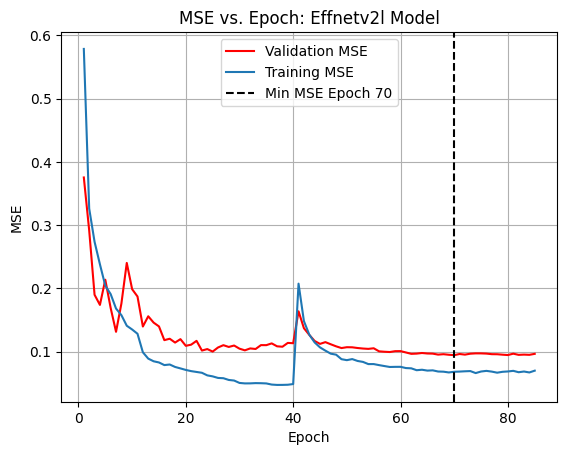

In [26]:
import matplotlib.pyplot as plt

def plot_mse(history):
    train_mse = history['mse']  
    test_mse = history['val_mse']  
    epochs = list(range(1, len(test_mse) + 1)) 

    min_mse_epoch = epochs[test_mse.index(min(test_mse))]  
    min_val_mse = min(test_mse)  

    plt.plot(epochs, test_mse, color='red', label='Validation MSE')
    plt.plot(epochs, train_mse, label='Training MSE')
    
    plt.axvline(x=min_mse_epoch, color='black', linestyle='--', label=f'Min MSE Epoch {min_mse_epoch}')
    
    plt.xlabel('Epoch')
    plt.ylabel('MSE')
    #plt.ylim(0,0.6)
    plt.title('MSE vs. Epoch: Effnetv2l Model')

    plt.legend()
    plt.grid(True)
    plt.show()

plot_mse(effnetv2lhistory)


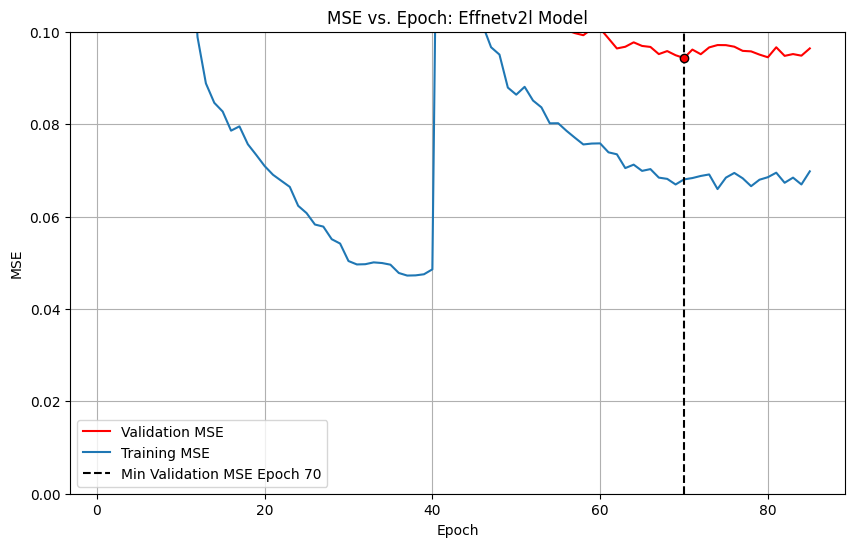

In [27]:
import matplotlib.pyplot as plt

# effnetv2lhistory = {}
# for key in effnetv2lhistory_1.history:
#     effnetv2lhistory[key] = effnetv2lhistory_1.history[key] + effnetv2lhistory_2.history[key]

def plot_mse(history, save_path=None):
    train_mse = history['mse']  
    test_mse = history['val_mse']  
    epochs = list(range(1, len(test_mse) + 1)) 

    min_mse_epoch = epochs[test_mse.index(min(test_mse))]  
    min_val_mse = min(test_mse)  

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, test_mse, color='red', label='Validation MSE')
    plt.plot(epochs, train_mse, label='Training MSE')
    
    plt.axvline(x=min_mse_epoch, color='black', linestyle='--', label=f'Min Validation MSE Epoch {min_mse_epoch}')
    plt.scatter(min_mse_epoch, min_val_mse, color='red', edgecolor='black', zorder=5)    
    
    plt.xlabel('Epoch')
    plt.ylabel('MSE')
    plt.ylim(0, 0.1)
    plt.title('MSE vs. Epoch: Effnetv2l Model')
    plt.legend()
    plt.grid(True)

    if save_path:
        plt.savefig(save_path, dpi=700)
    plt.show()

plot_mse(effnetv2lhistory, save_path='effnetv2lhistory.png')


In [28]:
effnetv2l_best_val_mse = min(effnetv2lhistory['val_mse'])  
print(f"Best Validation MSE: {effnetv2l_best_val_mse}")

Best Validation MSE: 0.09430302679538727


In [29]:
import pickle

with open('effnetv2lhistory_yolo.pkl', 'wb') as f:
    pickle.dump(effnetv2lhistory, f)

In [30]:
effnetv2lepochs = pd.DataFrame(effnetv2lhistory)
effnetv2lepochs.insert(0, 'epoch', range(1, len(effnetv2lepochs) + 1))
effnetv2lepochs.to_csv('effnetv2lhistoryyolo_history.csv', index=False)

In [ ]:
end = time.time()
end - start

# End Here